# 🐶🐱 Reconocimiento de Perros y Gatos con PyTorch
**Pipeline completo de producción:** Lazy Loading → Data Augmentation → Transfer Learning → Validation Loop → Early Stopping → Model Checkpointing → Métricas → ONNX Export

---

## 1. Descarga del Dataset (Kaggle)

In [ ]:
import kagglehub

path = kagglehub.dataset_download("tongpython/cat-and-dog", output_dir="data/")
print("Path to dataset files:", path)

## 2. Imports

In [17]:
import os
import random
import copy

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm

import torchvision
import torchvision.models as models
import torchvision.datasets as datasets
import torchvision.transforms as transforms

import torchmetrics

print("PyTorch version:", torch.__version__)
print("Device available:", "cuda" if torch.cuda.is_available() else "cpu")

PyTorch version: 2.11.0+cu130
Device available: cpu


## 3. Reproducibilidad — Fijar Semilla

In [18]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f"Semilla fijada: {SEED}")

Semilla fijada: 42


## 4. Data Augmentation y Lazy Loading (ImageFolder)

> **Plan Paso 1 & 2:** Se elimina la carga masiva en RAM. `ImageFolder` carga cada imagen
> solo cuando el DataLoader la necesita. Se aplica Data Augmentation al set de entrenamiento
> y normalización estándar de ImageNet a ambos sets.

In [19]:
TRAIN_DIR = 'data/training_set/training_set'
TEST_DIR  = 'data/test_set/test_set'
IMG_SIZE  = 224   # ResNet18 espera 224×224
BATCH_SIZE = 32

# Transformaciones de ENTRENAMIENTO (con augmentation)
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Transformaciones de VALIDACIÓN/TEST (sin augmentation)
transform_val = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=transform_train)
val_dataset   = datasets.ImageFolder(root=TEST_DIR,  transform=transform_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f"Clases detectadas : {train_dataset.classes}")
print(f"Total entrenamiento: {len(train_dataset)} imágenes")
print(f"Total validación   : {len(val_dataset)} imágenes")

Clases detectadas : ['cats', 'dogs']
Total entrenamiento: 8005 imágenes
Total validación   : 2023 imágenes


## 5. Visualización de Muestra

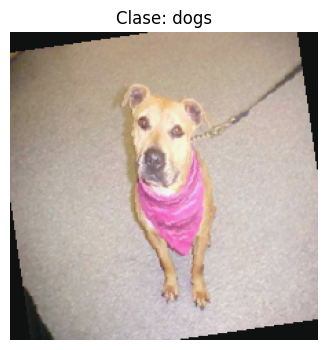

In [20]:
idx = random.randint(0, len(train_dataset) - 1)
img_tensor, label = train_dataset[idx]

# Desnormalizar para visualizar
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
img_vis = img_tensor.numpy().transpose(1, 2, 0)
img_vis = np.clip(std * img_vis + mean, 0, 1)

plt.figure(figsize=(4, 4))
plt.imshow(img_vis)
plt.title(f"Clase: {train_dataset.classes[label]}")
plt.axis('off')
plt.show()

In [21]:
class CNN(nn.Module):
   def __init__(self, in_channels, num_classes):

       """
       Building blocks of convolutional neural network.

       Parameters:
           * in_channels: Number of channels in the input image (for RGB, is 3 channels)
           * num_classes: Number of classes to predict. In our problem, 2.
       """
       super(CNN, self).__init__()

       # 1st convolutional layer
       self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=8, kernel_size=3, padding=1)
       # Max pooling layer
       self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
       # 2nd convolutional layer
       self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1)
       # Fully connected layer
       self.fc1 = nn.Linear(16 * 7 * 7, num_classes)

   def forward(self, x):
       """
       Define the forward pass of the neural network.

       Parameters:
           x: Input tensor.

       Returns:
           torch.Tensor
               The output tensor after passing through the network.
       """
       x = F.relu(self.conv1(x))  # Apply first convolution and ReLU activation
       x = self.pool(x)           # Apply max pooling
       x = F.relu(self.conv2(x))  # Apply second convolution and ReLU activation
       x = self.pool(x)           # Apply max pooling
       x = x.reshape(x.shape[0], -1)  # Flatten the tensor
       x = self.fc1(x)            # Apply fully connected layer
       return x
       x = x.reshape(x.shape[0], -1)  # Flatten the tensor
       x = self.fc1(x)            # Apply fully connected layer
       return x

In [22]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CNN(in_channels=3, num_classes=2).to(device)
print(model)

CNN(
  (conv1): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=784, out_features=2, bias=True)
)


In [23]:
# Define the loss function
criterion = nn.CrossEntropyLoss()

# Define the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [25]:
NUM_CLASSES = 2

criterion = nn.CrossEntropyLoss()

# Solo optimizamos la capa fc recién añadida
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

# Learning Rate Scheduler: reduce LR si la val_loss no mejora
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                   patience=2, factor=0.5)

# Métricas con torchmetrics
metrics = {
    'accuracy' : torchmetrics.Accuracy(task='binary').to(device),
    'precision': torchmetrics.Precision(task='binary').to(device),
    'recall'   : torchmetrics.Recall(task='binary').to(device),
    'f1'       : torchmetrics.F1Score(task='binary').to(device),
}
print('Configuración lista.')

AttributeError: 'CNN' object has no attribute 'fc'

## 6. Arquitectura — Transfer Learning con ResNet18

> **Plan Paso 3:** Se usa ResNet18 preentrenada en ImageNet. Las capas base se congelan
> (`requires_grad = False`) y solo se reemplaza y entrena la capa `fc` final.

In [26]:
NUM_EPOCHS = 10
PATIENCE   = 3   # Early stopping patience
CHECKPOINT_PATH = 'best_model.pth'

best_val_loss   = float('inf')
epochs_no_improv = 0
history = {'train_loss': [], 'val_loss': [],
           'val_acc': [], 'val_f1': []}

for epoch in range(1, NUM_EPOCHS + 1):

    # ── FASE ENTRENAMIENTO ──────────────────────────────────────────────
    model.train()
    running_loss = 0.0

    for data, targets in tqdm(train_loader,
                              desc=f'Epoch {epoch}/{NUM_EPOCHS} [Train]',
                              leave=False):
        data, targets = data.to(device), targets.to(device)

        # El orden correcto: zero_grad → forward → loss → backward → step
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * data.size(0)

    train_loss = running_loss / len(train_dataset)

    # ── FASE VALIDACIÓN ─────────────────────────────────────────────────
    model.eval()
    val_running_loss = 0.0

    # Resetear métricas
    for m in metrics.values():
        m.reset()

    with torch.no_grad():
        for data, targets in tqdm(val_loader,
                                  desc=f'Epoch {epoch}/{NUM_EPOCHS} [Val]',
                                  leave=False):
            data, targets = data.to(device), targets.to(device)

            outputs = model(data)
            loss = criterion(outputs, targets)
            val_running_loss += loss.item() * data.size(0)

            preds = torch.argmax(outputs, dim=1)
            for m in metrics.values():
                m.update(preds, targets)

    val_loss = val_running_loss / len(val_dataset)
    val_acc  = metrics['accuracy'].compute().item()
    val_f1   = metrics['f1'].compute().item()
    val_prec = metrics['precision'].compute().item()
    val_rec  = metrics['recall'].compute().item()

    # LR Scheduler
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    # Historial
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Acc: {val_acc:.4f} | F1: {val_f1:.4f} | "
          f"Prec: {val_prec:.4f} | Rec: {val_rec:.4f} | "
          f"LR: {current_lr:.6f}")

    # ── MODEL CHECKPOINTING ─────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights  = copy.deepcopy(model.state_dict())
        torch.save(best_weights, CHECKPOINT_PATH)
        print(f"  ✅ Checkpoint guardado (val_loss={best_val_loss:.4f})")
        epochs_no_improv = 0
    else:
        epochs_no_improv += 1
        print(f"  ⚠️  Sin mejora: {epochs_no_improv}/{PATIENCE}")

    # ── EARLY STOPPING ──────────────────────────────────────────────────
    if epochs_no_improv >= PATIENCE:
        print(f"\n🛑 Early Stopping activado en epoch {epoch}.")
        break

# Cargar los mejores pesos al final
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device, weights_only=True))
print("\n✅ Entrenamiento completo. Mejores pesos cargados.")

RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x50176 and 784x2)

## 7. Función de Pérdida, Optimizador y Métricas

> **Suggestion 1:** Se añaden métricas de F1, Precision y Recall con `torchmetrics`.

In [27]:
NUM_CLASSES = 2

criterion = nn.CrossEntropyLoss()

# Solo optimizamos la capa fc recién añadida
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

# Learning Rate Scheduler: reduce LR si la val_loss no mejora
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                   patience=2, factor=0.5,
                                                   verbose=True)

# Métricas con torchmetrics
metrics = {
    'accuracy' : torchmetrics.Accuracy(task='binary').to(device),
    'precision': torchmetrics.Precision(task='binary').to(device),
    'recall'   : torchmetrics.Recall(task='binary').to(device),
    'f1'       : torchmetrics.F1Score(task='binary').to(device),
}
print('Configuración lista.')

AttributeError: 'CNN' object has no attribute 'fc'

## 8. Loop de Entrenamiento con Validación, Early Stopping y Model Checkpointing

> **Suggestions 1:**
> - Bucle de validación con `model.eval()` + `torch.no_grad()` en cada época.
> - Early Stopping: detiene el entrenamiento si `val_loss` no mejora en `patience` épocas.
> - Checkpointing: guarda `best_model.pth` solo cuando `val_loss` mejora.

In [28]:
NUM_EPOCHS = 10
PATIENCE   = 3   # Early stopping patience
CHECKPOINT_PATH = 'best_model.pth'

best_val_loss   = float('inf')
epochs_no_improv = 0
history = {'train_loss': [], 'val_loss': [],
           'val_acc': [], 'val_f1': []}

for epoch in range(1, NUM_EPOCHS + 1):

    # ── FASE ENTRENAMIENTO ──────────────────────────────────────────────
    model.train()
    running_loss = 0.0

    for data, targets in tqdm(train_loader,
                              desc=f'Epoch {epoch}/{NUM_EPOCHS} [Train]',
                              leave=False):
        data, targets = data.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * data.size(0)

    train_loss = running_loss / len(train_dataset)

    # ── FASE VALIDACIÓN ─────────────────────────────────────────────────
    model.eval()
    val_running_loss = 0.0

    # Resetear métricas
    for m in metrics.values():
        m.reset()

    with torch.no_grad():
        for data, targets in tqdm(val_loader,
                                  desc=f'Epoch {epoch}/{NUM_EPOCHS} [Val]',
                                  leave=False):
            data, targets = data.to(device), targets.to(device)

            outputs = model(data)
            loss = criterion(outputs, targets)
            val_running_loss += loss.item() * data.size(0)

            preds = torch.argmax(outputs, dim=1)
            for m in metrics.values():
                m.update(preds, targets)

    val_loss = val_running_loss / len(val_dataset)
    val_acc  = metrics['accuracy'].compute().item()
    val_f1   = metrics['f1'].compute().item()
    val_prec = metrics['precision'].compute().item()
    val_rec  = metrics['recall'].compute().item()

    # LR Scheduler
    scheduler.step(val_loss)

    # Historial
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Acc: {val_acc:.4f} | F1: {val_f1:.4f} | "
          f"Prec: {val_prec:.4f} | Rec: {val_rec:.4f}")

    # ── MODEL CHECKPOINTING ─────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights  = copy.deepcopy(model.state_dict())
        torch.save(best_weights, CHECKPOINT_PATH)
        print(f"  ✅ Checkpoint guardado (val_loss={best_val_loss:.4f})")
        epochs_no_improv = 0
    else:
        epochs_no_improv += 1
        print(f"  ⚠️  Sin mejora: {epochs_no_improv}/{PATIENCE}")

    # ── EARLY STOPPING ──────────────────────────────────────────────────
    if epochs_no_improv >= PATIENCE:
        print(f"\n🛑 Early Stopping activado en epoch {epoch}.")
        break

# Cargar los mejores pesos al final
model.load_state_dict(torch.load(CHECKPOINT_PATH))
print("\n✅ Entrenamiento completo. Mejores pesos cargados.")

RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x50176 and 784x2)

## 9. Curvas de Aprendizaje

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'],   label='Val Loss')
axes[0].set_title('Loss por época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history['val_acc'], label='Val Accuracy', color='green')
axes[1].plot(history['val_f1'],  label='Val F1-Score', color='orange')
axes[1].set_title('Métricas de Validación')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Score')
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Exportar el Modelo a ONNX

> **Suggestion 3 — Formato ONNX:** Permite servir el modelo con ONNX Runtime, independientemente
> del framework, con mayor velocidad de inferencia.

In [ ]:
ONNX_PATH = 'best_model.onnx'

model.eval()
dummy_input = torch.randn(1, 3, 224, 224).to(device)

torch.onnx.export(
    model,
    dummy_input,
    ONNX_PATH,
    export_params=True,
    opset_version=17,
    do_constant_folding=True,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
)
print(f"✅ Modelo exportado a ONNX en: {ONNX_PATH}")

## 11. Servicio de Inferencia con FastAPI

> **Suggestion 3 — Servicio de Inferencia:** El siguiente código va en un archivo `app.py`
> separado. Se incluye aquí como referencia de producción.

In [ ]:
# ── CÓDIGO DE PRODUCCIÓN: guardar como `app.py` ─────────────────────────
# Ejecutar con: uvicorn app:app --host 0.0.0.0 --port 8000

fastapi_code = '''
from fastapi import FastAPI, File, UploadFile
from fastapi.responses import JSONResponse
from PIL import Image
import onnxruntime as ort
import numpy as np
import io

app = FastAPI(title="Dog vs Cat Classifier")

CLASSES = ["cat", "dog"]
IMG_SIZE = 224
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

ort_session = ort.InferenceSession("best_model.onnx")

def preprocess(image_bytes: bytes) -> np.ndarray:
    img = Image.open(io.BytesIO(image_bytes)).convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE))
    arr = np.array(img, dtype=np.float32) / 255.0
    arr = (arr - MEAN) / STD
    arr = arr.transpose(2, 0, 1)          # HWC -> CHW
    return arr[np.newaxis, ...]            # add batch dim

@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    image_bytes = await file.read()
    input_tensor = preprocess(image_bytes)
    outputs = ort_session.run(["output"], {"input": input_tensor})[0]
    predicted_class = CLASSES[int(np.argmax(outputs))]
    confidence = float(np.max(np.exp(outputs) / np.sum(np.exp(outputs))))
    return JSONResponse({"class": predicted_class, "confidence": round(confidence, 4)})

@app.get("/health")
def health():
    return {"status": "ok"}
'''

with open('app.py', 'w') as f:
    f.write(fastapi_code.strip())

print("✅ app.py generado. Ejecutar con: uvicorn app:app --host 0.0.0.0 --port 8000")

## 12. Contenerización con Docker

> **Suggestion 3 — Contenerización:** Crea un `Dockerfile` y un `docker-compose.yml`
> para encapsular la app y desplegarla en cualquier entorno sin conflictos de dependencias.

In [ ]:
dockerfile = '''FROM python:3.11-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY best_model.onnx .
COPY app.py .

EXPOSE 8000

CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]
'''

requirements = '''fastapi
uvicorn[standard]
onnxruntime
pillow
numpy
python-multipart
'''

docker_compose = '''version: "3.9"
services:
  dog-cat-api:
    build: .
    ports:
      - "8000:8000"
    restart: unless-stopped
    healthcheck:
      test: ["CMD", "curl", "-f", "http://localhost:8000/health"]
      interval: 30s
      timeout: 10s
      retries: 3
'''

with open('Dockerfile', 'w') as f:
    f.write(dockerfile)

with open('requirements.txt', 'w') as f:
    f.write(requirements)

with open('docker-compose.yml', 'w') as f:
    f.write(docker_compose)

print('✅ Dockerfile, requirements.txt y docker-compose.yml generados.')
print('\nComandos para desplegar:')
print('  docker build -t dog-cat-api .')
print('  docker-compose up -d')

## 13. Orquestación con Kubernetes

> **Suggestion 3 — Kubernetes:** Para escalar el servicio de inferencia bajo alta demanda.

In [ ]:
k8s_deployment = '''apiVersion: apps/v1
kind: Deployment
metadata:
  name: dog-cat-api
spec:
  replicas: 3
  selector:
    matchLabels:
      app: dog-cat-api
  template:
    metadata:
      labels:
        app: dog-cat-api
    spec:
      containers:
      - name: dog-cat-api
        image: dog-cat-api:latest
        ports:
        - containerPort: 8000
        resources:
          requests:
            memory: "256Mi"
            cpu: "250m"
          limits:
            memory: "512Mi"
            cpu: "500m"
---
apiVersion: v1
kind: Service
metadata:
  name: dog-cat-api-service
spec:
  selector:
    app: dog-cat-api
  ports:
  - protocol: TCP
    port: 80
    targetPort: 8000
  type: LoadBalancer
'''

with open('k8s-deployment.yaml', 'w') as f:
    f.write(k8s_deployment)

print('✅ k8s-deployment.yaml generado.')
print('\nComando para desplegar en Kubernetes:')
print('  kubectl apply -f k8s-deployment.yaml')